## **Выявление факторов, влияющих на интенсивность движения на трассе I-94**

Целью данного проекта является анализ интенсивности дорожного движения на трассе I-94 и выявление факторов, оказывающих на неё наибольшее влияние. В ходе исследования рассматриваются временные характеристики (время суток, день недели, месяц), а также погодные условия (температура, осадки, облачность и другие показатели).

Для достижения поставленной цели проводится разведочный анализ данных (EDA), включающий исследование распределений признаков, выявление закономерностей и оценку взаимосвязей между интенсивностью трафика и потенциально значимыми факторами. Полученные результаты позволяют определить основные условия, при которых наблюдается высокая или низкая интенсивность дорожного движения.

In [1]:
#Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv('Metro_Interstate_Traffic_Volume.csv')

In [3]:
df

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,None,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,None,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,None,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,None,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,None,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918
...,...,...,...,...,...,...,...,...,...
48199,None,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543
48200,None,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781
48201,None,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159
48202,None,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450


Изучим данный датасет более подробно:

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              48204 non-null  object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [5]:
print(df['date_time'].unique())

['2012-10-02 09:00:00' '2012-10-02 10:00:00' '2012-10-02 11:00:00' ...
 '2018-09-30 21:00:00' '2018-09-30 22:00:00' '2018-09-30 23:00:00']


---

Изучим распределение значений переменной `traffic_volume`: 

In [6]:
df['traffic_volume'].describe()

count    48204.000000
mean      3259.818355
std       1986.860670
min          0.000000
25%       1193.000000
50%       3380.000000
75%       4933.000000
max       7280.000000
Name: traffic_volume, dtype: float64

In [7]:
df['traffic_volume'].value_counts(bins=10).sort_index()

(-7.281000000000001, 728.0]    8095
(728.0, 1456.0]                5100
(1456.0, 2184.0]               2835
(2184.0, 2912.0]               4765
(2912.0, 3640.0]               4761
(3640.0, 4368.0]               4349
(4368.0, 5096.0]               7886
(5096.0, 5824.0]               5634
(5824.0, 6552.0]               3854
(6552.0, 7280.0]                925
Name: traffic_volume, dtype: int64

Построим гистограмму:

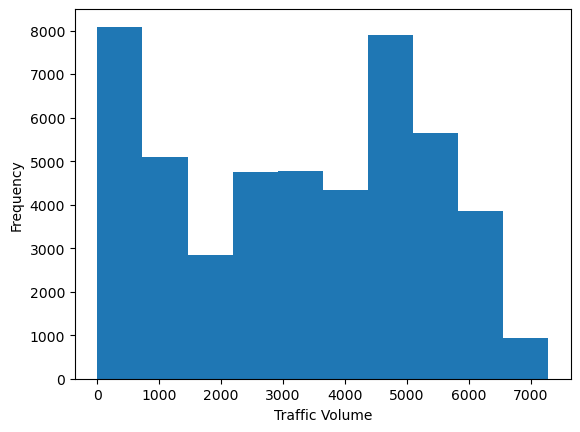

In [8]:
df['traffic_volume'].plot.hist()
plt.xlabel('Traffic Volume')
plt.show()

Исходя из распределения значений на гистограмме интенсивности трафика, можно сделать вывод о наличии двух наиболее выраженных диапазонов значений: от `0 до 700` и от `4400 до 5100`. При этом среднее значение интенсивности трафика составляет около `3300`, что свидетельствует о значительном разбросе данных и может быть связано с различиями в интенсивности трафика в дневное и ночное время суток.

---

#### Для более детального анализа отдельно рассмотрим интенсивность трафика в дневное и ночное время суток: 

Разделение данных выполнено следующим образом:

- дневной период - с 07:00 до 19:00;
- ночной период - с 19:00 до 07:00 следующего дня.

In [9]:
df['date_time'] = pd.to_datetime(df['date_time'])

daytime = df.loc[(df['date_time'].dt.hour >= 7) & (df['date_time'].dt.hour < 19), :].copy()
nighttime = df.loc[(df['date_time'].dt.hour >= 19) | (df['date_time'].dt.hour < 7), :]

In [10]:
daytime.shape

(23877, 9)

In [11]:
nighttime.shape

(24327, 9)

Для сравнения интенсивности трафика построим гистограммы:

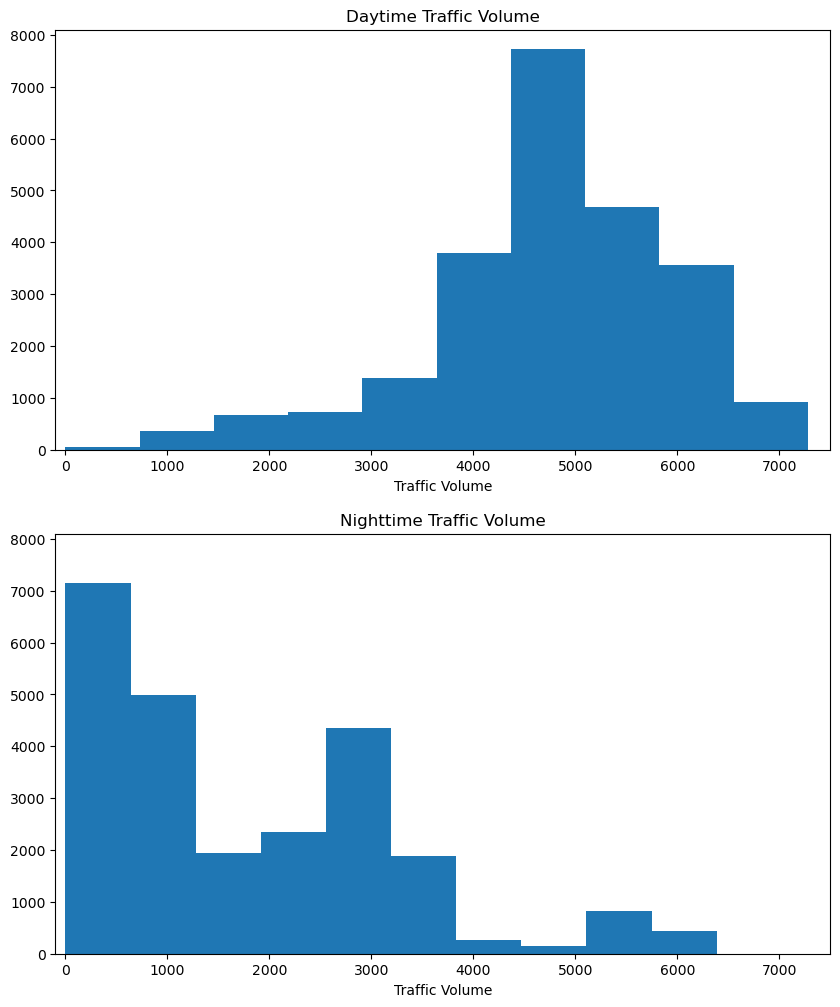

In [12]:
plt.figure(figsize=(10,12))
plt.subplot(2,1,1)
plt.hist(daytime['traffic_volume'])
plt.title('Daytime Traffic Volume')
plt.xlabel('Traffic Volume')
plt.xlim([-100, 7500])
plt.ylim([0, 8100])

plt.subplot(2,1,2)
plt.hist(nighttime['traffic_volume'])
plt.title('Nighttime Traffic Volume')
plt.xlabel('Traffic Volume')
plt.xlim([-100, 7500])
plt.ylim([0, 8100])

plt.show()

Гистограмма интенсивности трафика в дневное время характеризуется умеренной левосторонней асимметрией. При этом распределение близко к нормальному: основная масса наблюдений сосредоточена в центральной части распределения, а частота значений постепенно уменьшается по мере удаления от центра.

Гистограмма интенсивности трафика в ночное время имеет более выраженную правостороннюю асимметрию. Большинство наблюдений сосредоточено в области низких значений интенсивности, тогда как высокие значения встречаются значительно реже. В частности, интенсивность трафика лишь в исключительных случаях превышает `4000`.

In [13]:
daytime['traffic_volume'].describe()

count    23877.000000
mean      4762.047452
std       1174.546482
min          0.000000
25%       4252.000000
50%       4820.000000
75%       5559.000000
max       7280.000000
Name: traffic_volume, dtype: float64

In [14]:
nighttime['traffic_volume'].describe()

count    24327.000000
mean      1785.377441
std       1441.951197
min          0.000000
25%        530.000000
50%       1287.000000
75%       2819.000000
max       6386.000000
Name: traffic_volume, dtype: float64

Сравнение основных характеристик показывает, что средняя интенсивность трафика днём составляет `4762`, что примерно в 2,6 раза превышает соответствующий показатель ночью (`1785`).

Поскольку исследование направлено на изучение транспортного потока в условиях наиболее высокой загруженности трассы, дальнейший анализ будет проводиться на основе данных дневного трафика.

---

### **Временные индикаторы**

Одним из возможных индикаторов интенсивного движения является время. В определенный месяц, в определенный день или в определенное время суток на дороге может быть больше людей.

Мы рассмотрим несколько линейных графиков, показывающих, как изменяется объем трафика в зависимости от следующих факторов:

- Месяц
- День недели
- Время суток


#### Динамика среднего значения интенсивности трафика по месяцам:

In [15]:
daytime['month'] = daytime['date_time'].dt.month
by_month = daytime.groupby('month').mean(numeric_only=True)
by_month['traffic_volume']

month
1     4495.613727
2     4711.198394
3     4889.409560
4     4906.894305
5     4911.121609
6     4898.019566
7     4595.035744
8     4928.302035
9     4870.783145
10    4921.234922
11    4704.094319
12    4374.834566
Name: traffic_volume, dtype: float64

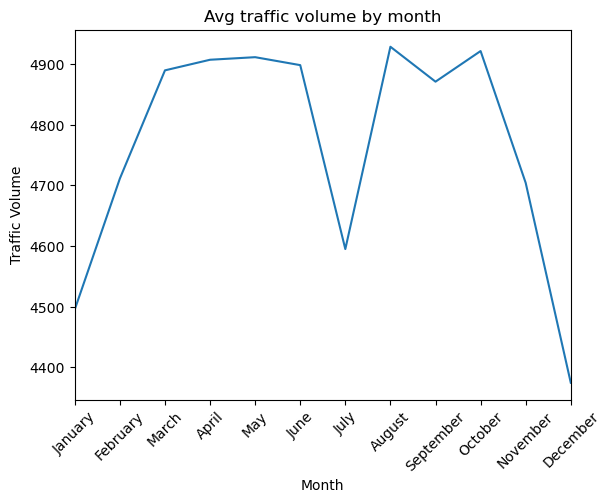

In [16]:
plt.plot(by_month.index, by_month['traffic_volume'])
plt.xlim([1,12])
plt.xticks(ticks = [1,2,3,4,5,6,7,8,9,10,11,12],
           labels = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'],
           rotation = 45)
plt.xlabel('Month')
plt.ylabel('Traffic Volume')
plt.title('Avg traffic volume by month')
plt.show()

Анализ линейного графика средней интенсивности дневного трафика по месяцам показал, что в течение года наблюдаются лишь незначительные колебания значений в диапазоне от `4400 до 4900`. Это позволяет предположить, что календарный месяц оказывает сравнительно слабое влияние на уровень дневного трафика. Наименьшая интенсивность движения фиксируется в зимние месяцы и в июле. Данная закономерность может быть связана с сезонными факторами, влияющими на транспортную активность.

---

#### Динамика среднего значения интенсивности трафика по дням недели:

In [17]:
daytime['dayofweek'] = daytime['date_time'].dt.dayofweek
by_dayofweek = daytime.groupby('dayofweek').mean(numeric_only=True)
by_dayofweek['traffic_volume']

dayofweek
0    4893.551286
1    5189.004782
2    5284.454282
3    5311.303730
4    5291.600829
5    3927.249558
6    3436.541789
Name: traffic_volume, dtype: float64

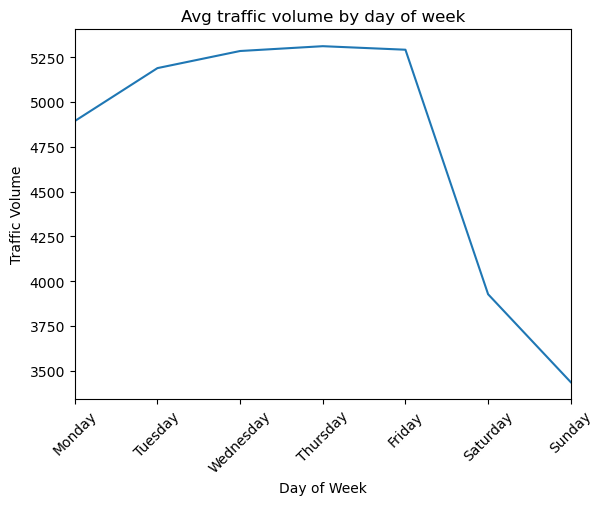

In [18]:
plt.plot(by_dayofweek.index, by_dayofweek['traffic_volume'])
plt.xlim([0, 6])
plt.xticks(ticks = [0,1,2,3,4,5,6],
           labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
           rotation = 45)
plt.xlabel('Day of Week')
plt.ylabel('Traffic Volume')
plt.title('Avg traffic volume by day of week')
plt.show()

По графику наблюдается существенное снижение интенсивности трафика при переходе от будних дней к выходным. Среднее значение показателя уменьшается с 4900 до 3500, что соответствует снижению примерно на 29%. Полученные результаты свидетельствуют о значительном влиянии типа дня недели на интенсивность дорожного движения.

---

#### Динамика среднего значения интенсивности трафика в зависимости от времени суток:

Поскольку выходные дни характеризуются более низкими значениями интенсивности трафика по сравнению с будними, их включение в общую выборку может искажать средние показатели. Поэтому анализ будет выполнен отдельно для рабочих и выходных дней.

In [19]:
daytime['hour'] = daytime['date_time'].dt.hour

business_days = daytime.loc[daytime['dayofweek'] <= 4, :].copy() # 4 == Friday
weekend = daytime.loc[daytime['dayofweek'] >= 5, :].copy() # 5 == Saturday

by_hour_business = business_days.groupby('hour').mean(numeric_only=True)
by_hour_weekend = weekend.groupby('hour').mean(numeric_only=True)

print(by_hour_business['traffic_volume'])
print(by_hour_weekend['traffic_volume'])

hour
7     6030.413559
8     5503.497970
9     4895.269257
10    4378.419118
11    4633.419470
12    4855.382143
13    4859.180473
14    5152.995778
15    5592.897768
16    6189.473647
17    5784.827133
18    4434.209431
Name: traffic_volume, dtype: float64
hour
7     1589.365894
8     2338.578073
9     3111.623917
10    3686.632302
11    4044.154955
12    4372.482883
13    4362.296564
14    4358.543796
15    4342.456881
16    4339.693805
17    4151.919929
18    3811.792279
Name: traffic_volume, dtype: float64


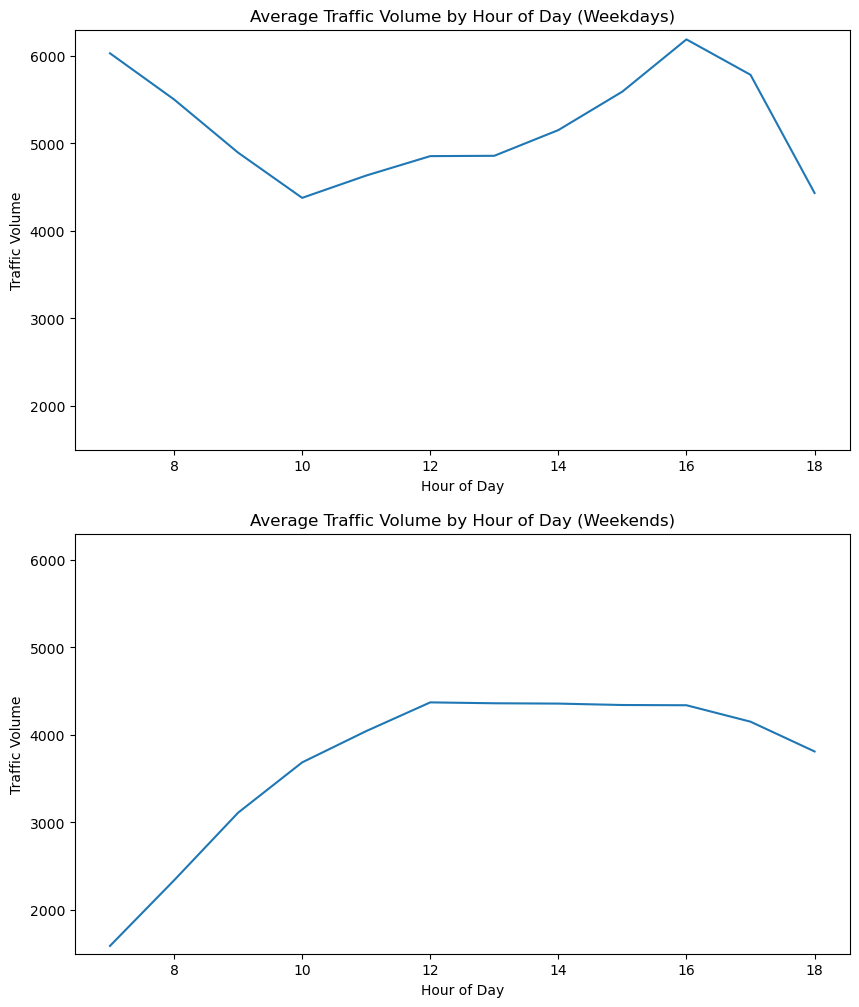

In [20]:
plt.figure(figsize=(10,12))

plt.subplot(2,1,1)
plt.plot(by_hour_business.index, by_hour_business['traffic_volume'])
plt.title('Average Traffic Volume by Hour of Day (Weekdays)')
plt.xlabel('Hour of Day')
plt.ylabel('Traffic Volume')
plt.ylim([1500, 6300])

plt.subplot(2,1,2)
plt.plot(by_hour_weekend.index, by_hour_weekend['traffic_volume'])
plt.title('Average Traffic Volume by Hour of Day (Weekends)')
plt.xlabel('Hour of Day')
plt.ylabel('Traffic Volume')
plt.ylim([1500, 6300])

plt.show()

Исходя из анализа графика изменения интенсивности трафика в будние дни по часам, можно сделать вывод, что наибольшие значения наблюдаются в 7:00 (`6030`) и в 16:00 (`6189`), что соответствует классическим "часам пик" при поездках на работу и обратно. Далее в период с 7:00 до 10:00 интенсивность снижается (с `6030` до `4378`), после чего вновь возрастает, достигая пикового значения в 16:00. В интервале с 16:00 до 18:00 наблюдается снижение интенсивности (с `6189` до `4434`).

В выходные дни картина иная. Минимальная интенсивность наблюдается в 7:00 (`1589`), после чего показатель постепенно увеличивается до 12:00 (`4372`). В период с 12:00 до 16:00 трафик остаётся относительно стабильным, находясь на среднем уровне (`4359`). Далее с 16:00 до 18:00 наблюдается снижение интенсивности трафика, аналогичное будним дням, однако менее выраженное (с `4339` до `3811`). Общая форма зависимости напоминает логарифмическую: резкий рост в утренние часы сменяется плато в дневной период и последующим спадом вечером.

#### **Вывод**:

Если выделить общие закономерности, можно сделать следующие выводы:

* Тип дня недели оказывает существенное влияние на интенсивность трафика: в будние и выходные дни наблюдаются различия как по уровню, так и по характеру распределения нагрузки в течение суток.

* Для будних дней характерно наличие двух выраженных пиков интенсивности трафика - в 7:00 и 16:00, что соответствует утреннему и вечернему часам пик. Между ними наблюдается временное снижение транспортной активности.

* В выходные дни выраженные пики отсутствуют. После низких значений в утренние часы интенсивность трафика постепенно возрастает до полудня, а затем стабилизируется на относительно постоянном уровне вплоть до 16:00.

* В период с 16:00 до 18:00 как в будние, так и в выходные дни наблюдается снижение интенсивности трафика, однако в выходные дни данный спад выражен менее существенно.

---

### **Погодные условия**

Ниже приведены признаки, используемые для описания погодных условий в наборе данных. Они включают как числовые, так и категориальные переменные:

In [21]:
daytime[['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description']]

,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description
0,288.28,0.00,0.0,40,Clouds,scattered clouds
1,289.36,0.00,0.0,75,Clouds,broken clouds
2,289.58,0.00,0.0,90,Clouds,overcast clouds
3,290.13,0.00,0.0,90,Clouds,overcast clouds
4,291.14,0.00,0.0,75,Clouds,broken clouds
...,...,...,...,...,...,...
48194,283.84,0.00,0.0,75,Rain,proximity shower rain
48195,283.84,0.00,0.0,75,Drizzle,light intensity drizzle
48196,284.38,0.00,0.0,75,Rain,light rain
48197,284.79,0.00,0.0,75,Clouds,broken clouds


| Переменная          | Тип         | Описание                                        | Единицы |
|--------------------|------------|------------------------------------------------|---------|
| temp               | Continuous | Средняя температура воздуха                    | Kelvin  |
| rain_1h            | Continuous | Количество осадков (дождь) за последний час   | mm      |
| snow_1h            | Continuous | Количество осадков (снег) за последний час    | mm      |
| clouds_all         | Integer    | Процент облачности                             | %       |
| weather_main       | Categorical| Краткое описание текущих погодных условий      | -       |
| weather_description| Categorical| Подробное описание текущих погодных условий    | -       |

Рассмотрим взаимосвязь между погодными условиями и интенсивностью трафика в дневное время суток:

In [22]:
daytime[['traffic_volume', 'temp', 'rain_1h', 'snow_1h', 'clouds_all']].corr().loc['traffic_volume',['temp', 'rain_1h', 'snow_1h', 'clouds_all']]

temp          0.128317
rain_1h       0.003697
snow_1h       0.001265
clouds_all   -0.032932
Name: traffic_volume, dtype: float64

Наибольшее значение коэффициента корреляции наблюдается между интенсивностью трафика и температурой воздуха `temp`. Для более детального анализа данной зависимости построим диаграмму рассеяния:

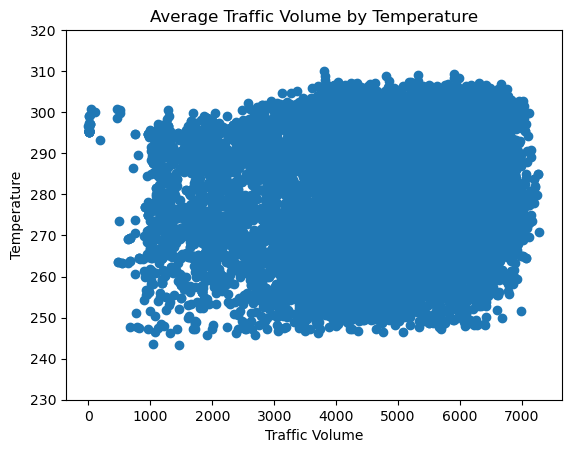

In [23]:
plt.scatter(daytime['traffic_volume'], daytime['temp'])
plt.ylabel('Temperature')
plt.ylim(230, 320)
plt.xlabel('Traffic Volume')
plt.title('Average Traffic Volume by Temperature')
plt.show()

Диаграмма рассеяния демонстрирует, что при фиксированных значениях температуры интенсивность трафика может принимать как низкие, так и высокие значения. Это указывает на отсутствие выраженной зависимости между данными переменными и позволяет сделать вывод о том, что температура не является надежным индикатором интенсивности трафика.

Проанализируем категориальные переменные, характеризующие погодные условия: `weather_main` и `weather_description`:

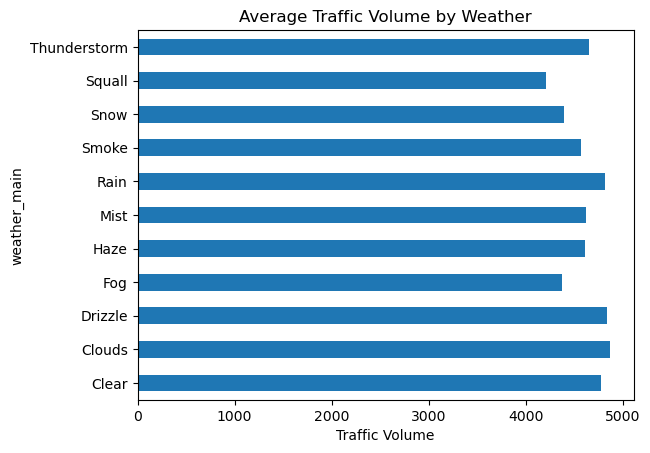

In [24]:
by_weather_main = daytime.groupby('weather_main').mean(numeric_only=True)
by_weather_description = daytime.groupby('weather_description').mean(numeric_only=True)

by_weather_main['traffic_volume'].plot.barh()
plt.xlabel('Traffic Volume')
plt.title('Average Traffic Volume by Weather')
plt.show()

По столбчатой диаграмме, отражающей среднюю интенсивность трафика в зависимости от общих погодных условий, не выявлено случаев превышения отметки 5000. Однако можно выделить типы погодных условий, при которых наблюдаются её наибольшие значения: `Clear`, `Clouds`, `Drizzle`, `Rain`, `Thunderstorm`.

Полученные результаты представляются интересными, поскольку повышенная интенсивность трафика наблюдается как при ясной погоде, так и при неблагоприятных погодных условиях, таких как дождь и гроза. Это может быть связано с тем, что в условиях ухудшения погоды часть водителей предпочитает использовать личный автомобиль вместо альтернативных видов транспорта.

Далее рассмотрим более детальное распределение интенсивности трафика с использованием расширенной классификации погодных условий:

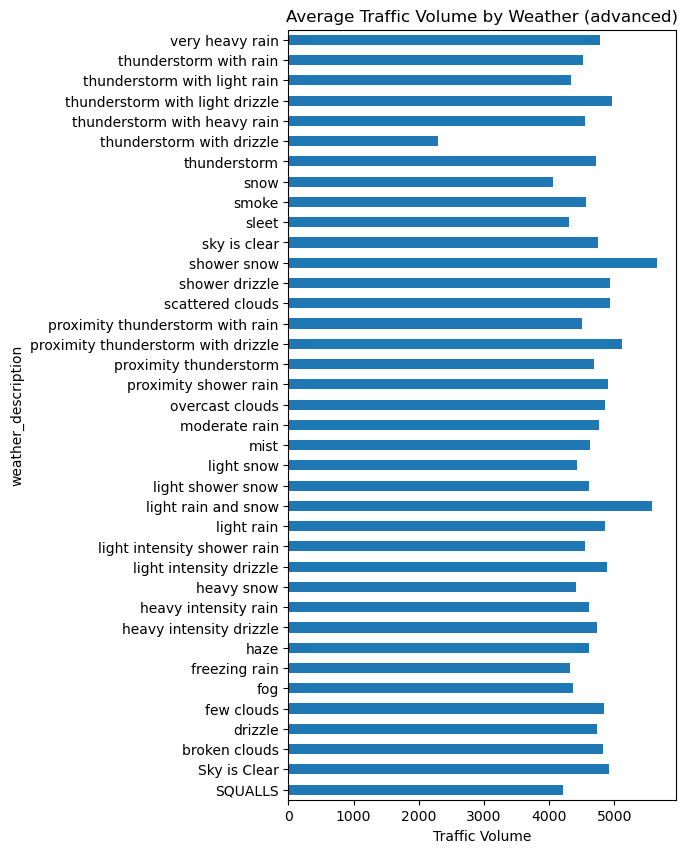

In [25]:
by_weather_description['traffic_volume'].plot.barh(figsize=(5,10))
plt.xlabel('Traffic Volume')
plt.title('Average Traffic Volume by Weather (advanced)')
plt.show()

На диаграмме с расширенным представлением погодных условий отчётливо видно, что в ряде случаев значение интенсивности трафика достигает 5000 и даже превышает его. Наиболее высокие значения наблюдаются при погодных условиях `light rain and snow`, `proximity thunderstorm and drizzle` и `shower snow`.

Примечательно, что повышенная интенсивность трафика фиксируется при погодных условиях, которые потенциально могут затруднять движение. Это указывает на то, что погодные условия в данных случаях не оказывают существенного влияния на интенсивность транспортного потока, что может быть обусловлено устойчивостью движения на трассе I-94, а также высоким качеством дорожного покрытия, обеспечивающим стабильность трафика даже в неблагоприятных погодных условиях.

### **Заключение:**

В рамках данного проекта были выявлены основные факторы, влияющие на интенсивность трафика на трассе I-94. Установлено, что наибольшее влияние оказывают временные характеристики:

- интенсивность трафика выше в будние дни по сравнению с выходными;

- в будние дни наблюдаются выраженные часы пик - около 7:00 и 16:00;

- месячная сезонность выражена слабо: колебания средней интенсивности находятся в диапазоне от 4400 до 4900, что указывает на ограниченное влияние данного фактора.

Анализ погодных условий показал, что их влияние на интенсивность трафика является незначительным. Независимо от типа погоды, существенных и устойчивых изменений уровня трафика не наблюдается, что может быть связано с высокой устойчивостью транспортного потока и качеством дорожной инфраструктуры.

Таким образом, основными факторами, влияющими на интенсивность трафика, являются день недели и время суток, тогда как погодные условия и сезонные (месячные) изменения оказывают менее выраженное влияние.